# Mid-term project: Housing price prediction
## Author: Yuxiang MA
## Date: 2025-10-23
## Version: 1.0

### 包的调用和数据录入

In [144]:
# 基础包
import pandas as pd, numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error

In [145]:
# 读入
test = pd.read_csv('ruc_Class25Q2_test_price.csv')

# 去除列名中的所有空格
test.columns = [col.replace(" ", "") for col in test.columns]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10756\3709702317.py:2: DtypeWarning: Columns (4,32) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv('ruc_Class25Q2_test_price.csv')


### 查看数据情况（空缺值、总数）

### 数据清洗中

In [146]:
# 去除单位，并且将非区间数据的转化为数字

# 需要清洗的列 "建筑面积", "套内面积", "房屋总数", "楼栋总数", "绿化率", "物业费", "燃气费", "供热费"
test['建筑面积'] = test['建筑面积'].str.replace('㎡', '', regex=False)
test['建筑面积'] = test['建筑面积'].astype(float)

test['套内面积'] = test['套内面积'].str.replace('㎡', '', regex=False)
test['套内面积'] = test['套内面积'].astype(float)

test['房屋总数'] = test['房屋总数'].str.replace('户', '', regex=False)
test['房屋总数'] = test['房屋总数'].astype(float)

test['楼栋总数'] = test['楼栋总数'].str.replace('栋', '', regex=False)
test['楼栋总数'] = test['楼栋总数'].astype(float)

test['绿化率'] = test['绿化率'].str.replace('%', '', regex=False)
test['绿化率'] = test['绿化率'].astype(float)

# 存在-的区间
test['物业费'] = test['物业费'].str.replace('元/月/㎡', '', regex=False)
test['燃气费'] = test['燃气费'].str.replace('元/m³', '', regex=False)
test['供热费'] = test['供热费'].str.replace('元/㎡', '', regex=False)

test.sample(10)

,ID,城市,区域,板块,环线,房屋户型,所在楼层,建筑面积,套内面积,房屋朝向,...,供水,供暖,供电,燃气费,供热费,停车位,停车费用,coord_x,coord_y,客户反馈
22813,1022813,4,108.0,178.0,内环内,2室0厅1厨1卫,中楼层 (共12层),70.14,NaN,南,...,民水,NaN,民电,NaN,NaN,87.0,NaN,122.551015,32.272749,总归来说，人流量中等，仔细体会，周边建设中
20854,1020854,4,58.0,630.0,内环至中环,1室1厅1厨1卫,低楼层 (共6层),40.00,31.4,南,...,商水/民水,自采暖,民电,0.8-3,NaN,600.0,150,122.482771,32.155669,视野好，反过来看，通风流畅，隔音好
22195,1022195,4,23.0,664.0,外环外,1室1厅1厨1卫,低楼层 (共5层),57.82,NaN,北 南,...,民水,自采暖,民电,3,NaN,1030.0,150,122.356476,32.263315,反过来看，夜间吵闹，采光极好，暖气慢
21428,1021428,4,23.0,664.0,外环外,3室2厅1厨1卫,低楼层 (共12层),118.51,NaN,南 北,...,民水,自采暖,民电,3,NaN,500.0,300.00,122.387694,32.282636,标准水平，走廊积灰，从体验上看，门窗松动，差不多这样，走廊积灰
23309,1023309,4,120.0,939.0,NaN,3室2厅1厨2卫,低楼层 (共13层),122.25,NaN,南,...,民水,自采暖,民电,3,NaN,380.0,150,122.435254,32.119909,个人觉得，厕所漏水，使用年限适中
26540,1026540,7,131.0,457.0,NaN,3室2厅1厨1卫,低楼层 (共18层),103.09,NaN,西南,...,民水,NaN,民电,3.5,NaN,372.0,200,115.156624,23.621419,管道漏水，不过呢，上下水正常，相对来说，隔音好
16349,1016349,3,20.0,431.0,内环至中环,4室2厅1厨2卫,低楼层 (共7层),141.15,NaN,南 北,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,121.740655,32.248814,房型规整，细看下来，噪声扰民
994,1000994,0,62.0,911.0,NaN,3室1厅1厨1卫,低楼层 (共17层),92.58,NaN,南 北,...,民水,自采暖,民电,2.61,NaN,800.0,400,117.184561,40.771595,简单来说，装修好，总的来说，生活圈成熟，反正，空调老旧
25981,1025981,6,59.0,64.0,NaN,3室2厅1厨2卫,高楼层 (共11层),106.90,NaN,南 北,...,民水,集中供暖,民电,2.63-3.7,25-26,2000.0,200,116.849208,41.355599,周边建设中，总归来说，道路宽度标准
25538,1025538,6,71.0,616.0,NaN,2室0厅1厨1卫,高楼层 (共7层),56.70,NaN,东 西,...,民水,集中供暖,商电/民电,NaN,1.97,30.0,3,115.921538,41.809597,电路不稳，价格合理，地段好


### 将一些数值数据进行拆分，转化为数字

In [147]:
# (1)房屋户型
# 定义一个函数解析户型
print(test['房屋户型'].value_counts()) # 388类，只有室厅厨卫和房间卫两种格式

房屋户型
2室1厅1厨1卫    8263
3室2厅1厨2卫    5437
2室2厅1厨1卫    3945
3室2厅1厨1卫    3674
3室1厅1厨1卫    2756
            ... 
8室3厅1厨3卫       1
5室2厅2厨1卫       1
8室1厅1厨3卫       1
8室2厅1厨4卫       1
4室1厅2厨2卫       1
Name: count, Length: 191, dtype: int64


In [148]:
def parse_huxing(huxing):
    if pd.isna(huxing):
        return pd.Series([None, None, None, None, None])  # 统一返回5列
    # 尝试匹配“x室x厅x厨x卫”
    match1 = re.match(r'(\d+)室(\d+)厅(\d+)厨(\d+)卫', huxing)
    if match1:
        return pd.Series([int(match1.group(1)), int(match1.group(2)), int(match1.group(3)), int(match1.group(4)), None])
    # 尝试匹配“x房间x卫”
    match2 = re.match(r'(\d+)房间(\d+)卫', huxing)
    if match2:
        return pd.Series([None, None, None, int(match2.group(2)), int(match2.group(1))])
    # 没匹配上返回空
    return pd.Series([None, None, None, None, None])

# 应用函数，生成新列
test[['房型_室', '房型_厅', '房型_厨', '房型_卫', '房型_房间']] = test['房屋户型'].apply(parse_huxing)

# 当 '房型_房间' 为缺失值时，用其他列的和填充
test.loc[test['房型_房间'].isna(), '房型_房间'] = (
    test['房型_室'] + test['房型_厅'] + test['房型_厨'] + test['房型_卫']
)

In [149]:
# test = test.loc[:, ~test.T.duplicated()]
test[['房屋户型', '房型_室', '房型_厅', '房型_厨', '房型_卫', '房型_房间']].sample(100)

,房屋户型,房型_室,房型_厅,房型_厨,房型_卫,房型_房间
1332,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
4722,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
22590,2室2厅1厨1卫,2.0,2.0,1.0,1.0,6.0
8754,3室2厅1厨1卫,3.0,2.0,1.0,1.0,7.0
17303,2室2厅1厨2卫,2.0,2.0,1.0,2.0,7.0
...,...,...,...,...,...,...
24168,4室2厅1厨1卫,4.0,2.0,1.0,1.0,8.0
27611,4室2厅1厨3卫,4.0,2.0,1.0,3.0,10.0
6653,2室1厅1厨1卫,2.0,1.0,1.0,1.0,5.0
16534,1室1厅1厨1卫,1.0,1.0,1.0,1.0,4.0


In [150]:
# (2)拆分为：相对位置，总共楼层（可能有0值）
test['所在楼层'].value_counts() # 258类，高中低楼层，顶层，底层，地下室，地下室（共0层）174个

所在楼层
中楼层 (共6层)     2209
高楼层 (共6层)     2000
低楼层 (共6层)     1470
中楼层 (共18层)     950
高楼层 (共18层)     880
              ... 
高楼层 (共54层)       1
中楼层 (共54层)       1
低楼层 (共53层)       1
高楼层 (共53层)       1
高楼层 (共49层)       1
Name: count, Length: 218, dtype: int64

In [151]:
# 提取相对楼层（括号前的部分）
test['相对楼层'] = test['所在楼层'].str.split(' \(').str[0]

# 对 '相对楼层' 做 one-hot 编码
floor_dummies = pd.get_dummies(test['相对楼层'], prefix='相对楼层')

# 拼接回原始数据集，但保留原有列
test = pd.concat([test, floor_dummies], axis=1)


In [152]:
# 筛选相对楼层开头的列
floor_cols = [col for col in test.columns if col.startswith('相对楼层_')]

# 查看原始相对楼层 + 对应的 one-hot 列
test[['相对楼层'] + floor_cols].sample(10, random_state=111)

,相对楼层,相对楼层_中楼层,相对楼层_低楼层,相对楼层_地下室,相对楼层_底层,相对楼层_顶层,相对楼层_高楼层
23361,中楼层,True,False,False,False,False,False
33864,中楼层,True,False,False,False,False,False
24086,中楼层,True,False,False,False,False,False
7092,高楼层,False,False,False,False,False,True
4519,中楼层,True,False,False,False,False,False
246,中楼层,True,False,False,False,False,False
26311,中楼层,True,False,False,False,False,False
30940,中楼层,True,False,False,False,False,False
4156,低楼层,False,True,False,False,False,False
6347,中楼层,True,False,False,False,False,False


In [153]:
# 提取总楼层（括号里的数字）
test['总共楼层'] = test['所在楼层'].str.extract(r'共(\d+)层')[0].astype(float)

In [154]:
# test = test.loc[:, ~test.T.duplicated()]
test[['所在楼层', '总共楼层']].sample(100)

,所在楼层,总共楼层
20126,低楼层 (共6层),6.0
28353,高楼层 (共6层),6.0
12484,低楼层 (共42层),42.0
22983,低楼层 (共3层),3.0
33986,高楼层 (共18层),18.0
...,...,...
25435,高楼层 (共6层),6.0
16835,低楼层 (共18层),18.0
17848,低楼层 (共16层),16.0
18304,中楼层 (共6层),6.0


In [155]:
# (3)生成房屋朝向的dummy
test['房屋朝向'].value_counts() # 173类，有复合方向

房屋朝向
南              13239
南 北             9887
东南              3305
东               1250
西南              1212
               ...  
东 南 北 东南 东北        1
南 东南 北             1
东南 东 西北 西          1
东 南 东北             1
南 北 东南 西南          1
Name: count, Length: 119, dtype: int64

In [156]:
# 创建一个函数来处理房屋朝向
def process_orientation(orientation):
    if pd.isna(orientation):
        return pd.Series([0, 0, 0, 0], index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])
    
    # 初始化四个方向的权重
    weights = {'东': 0, '南': 0, '西': 0, '北': 0}
    
    # 将方向拆分为列表
    directions = orientation.split()
    
    # 遍历每个方向
    for direction in directions:
        if len(direction) == 1:  # 单个方向
            weights[direction] = 1
        elif len(direction) == 2:  # 复合方向
            weights[direction[0]] += 0.5
            weights[direction[1]] += 0.5
    
    # 确保每个方向的权重不超过1
    for direction in weights:
        weights[direction] = min(weights[direction], 1)
    
    return pd.Series([weights['东'], weights['南'], weights['西'], weights['北']], 
                    index=['朝向_东', '朝向_南', '朝向_西', '朝向_北'])

# # 测试几个例子
# test_cases = pd.Series([
#     '东',
#     '东南',
#     '东 东南',
#     '西 西南',
#     '南 东南 西南'
# ])

# # 显示测试结果
# print("测试用例结果：")
# for case in test_cases:
#     print(f"\n输入: {case}")
#     print(process_orientation(case))

# 应用到实际数据
orientation_df = test['房屋朝向'].apply(process_orientation)
test = pd.concat([test, orientation_df], axis=1)

In [157]:
# 显示几个实际数据的结果
print("\n实际数据样例：")
print(test[['房屋朝向', '朝向_东', '朝向_南', '朝向_西', '朝向_北']].sample(10))


实际数据样例：
       房屋朝向  朝向_东  朝向_南  朝向_西  朝向_北
7845    南 北   0.0   1.0   0.0   1.0
13669    东南   0.5   0.5   0.0   0.0
6034    南 北   0.0   1.0   0.0   1.0
28838   南 北   0.0   1.0   0.0   1.0
33050    东南   0.5   0.5   0.0   0.0
14250    东南   0.5   0.5   0.0   0.0
26555  西南 西   0.0   0.5   1.0   0.0
7189    南 北   0.0   1.0   0.0   1.0
17199     南   0.0   1.0   0.0   0.0
23540     南   0.0   1.0   0.0   0.0


In [158]:
# (4)查看建筑结构取值及频数
test['建筑结构'].value_counts() # 7类，没有明显包含关系

建筑结构
钢混结构    25065
混合结构     3460
砖混结构     2715
未知结构     1846
框架结构      651
钢结构       230
砖木结构       36
Name: count, dtype: int64

In [159]:
# 生成哑变量，并确保输出为0和1
structure_dummies = pd.get_dummies(test['建筑结构'], prefix='结构').astype(int)
# 合并回原数据集
test = pd.concat([test, structure_dummies], axis=1)

In [160]:
# 获取所有以"结构_"开头的列
structure_columns = [col for col in test.columns if col.startswith('结构_')]
# 显示这些列的样本数据
# test = test.loc[:, ~test.T.duplicated()]
print("随机10行数据：")
print(test[['建筑结构'] + structure_columns].sample(10))

随机10行数据：
       建筑结构  结构_未知结构  结构_框架结构  结构_混合结构  结构_砖木结构  结构_砖混结构  结构_钢混结构  结构_钢结构
16922  钢混结构        0        0        0        0        0        1       0
32845  钢混结构        0        0        0        0        0        1       0
11715  钢混结构        0        0        0        0        0        1       0
11912  钢混结构        0        0        0        0        0        1       0
16253  钢混结构        0        0        0        0        0        1       0
26808  钢混结构        0        0        0        0        0        1       0
21357  钢混结构        0        0        0        0        0        1       0
31725  钢混结构        0        0        0        0        0        1       0
31358  钢混结构        0        0        0        0        0        1       0
21113  钢混结构        0        0        0        0        0        1       0


In [161]:
# (5) 装修情况
test['装修情况'].value_counts() # 4类，精、简、毛坯、其他

装修情况
精装    15971
简装     7988
其他     7134
毛坯     2910
Name: count, dtype: int64

In [162]:
# 生成哑变量
deco_dummies = pd.get_dummies(test['装修情况'], prefix='装修')
# 合并回原数据集
test = pd.concat([test, deco_dummies], axis=1)

In [163]:
# 获取所有以"装修_"开头的列
decoration_columns = [col for col in test.columns if col.startswith('装修_')]
# 显示这些列的样本数据
print("随机10行数据：")
print(test[['装修情况'] + decoration_columns].sample(10))

随机10行数据：
      装修情况  装修_其他  装修_毛坯  装修_简装  装修_精装
21680   精装  False  False  False   True
10683   毛坯  False   True  False  False
30175   其他   True  False  False  False
25726   精装  False  False  False   True
13692   简装  False  False   True  False
20746   精装  False  False  False   True
5977    简装  False  False   True  False
6448    精装  False  False  False   True
1478    精装  False  False  False   True
23908   简装  False  False   True  False


In [164]:
# (6)梯户比例
test['梯户比例'].value_counts() # 327类,里面会出现几十几的情况

梯户比例
一梯两户      8356
两梯四户      3918
一梯四户      3098
一梯三户      2871
两梯六户      1993
          ... 
两梯二十七户       1
一梯五十九户       1
六梯八户         1
五梯十七户        1
五梯二十二户       1
Name: count, Length: 256, dtype: int64

In [165]:
# 中文数字字典
cn2num = {
    '一': 1, '二': 2,'两': 2, '三': 3, '四': 4, '五': 5,
    '六': 6, '七': 7, '八': 8, '九': 9, '十': 10
}

def cn_to_num(cn_str):
    """将中文数字转换为阿拉伯数字"""
    if not cn_str:
        return 0
        
    # 如果只有一个字，直接返回对应数字
    if len(cn_str) == 1:
        return cn2num.get(cn_str, 0)
    
    # 处理十位数
    if cn_str.startswith('十'):
        # "十" -> 10, "十一" -> 11
        if len(cn_str) == 1:
            return 10
        return 10 + cn2num.get(cn_str[1], 0)
    
    if '十' in cn_str:
        # "二十" -> 20, "二十一" -> 21
        parts = cn_str.split('十')
        return cn2num.get(parts[0], 0) * 10 + cn2num.get(parts[1], 0) if parts[1] else cn2num.get(parts[0], 0) * 10
    
    # 其他情况（理论上不会出现）
    return 0

def parse_tihu(s):
    """解析梯户比例，返回电梯数和户数"""
    if pd.isna(s):
        return pd.Series([None, None], index=['梯户_电梯', '梯户_每层户数'])
    
    # 使用正则表达式提取数字部分
    pattern = r'(.+?)梯(.+?)户'
    match = re.match(pattern, s)
    if not match:
        return pd.Series([None, None], index=['梯户_电梯', '梯户_每层户数'])
    
    # 转换中文数字为阿拉伯数字
    elevators = cn_to_num(match.group(1))
    households = cn_to_num(match.group(2))
    
    return pd.Series([elevators, households], index=['梯户_电梯', '梯户_每层户数'])

# 应用到实际数据
test[['梯户_电梯', '梯户_每层户数']] = test['梯户比例'].apply(parse_tihu)

In [166]:
# test = test.loc[:, ~test.T.duplicated()]
# 显示实际数据样例
print("\n随机10行数据示例：")
print(test[['梯户比例', '梯户_电梯', '梯户_每层户数']].sample(10))


随机10行数据示例：
         梯户比例  梯户_电梯  梯户_每层户数
10752   两梯十八户    2.0     18.0
8314     一梯两户    1.0      2.0
31982    三梯六户    3.0      6.0
2478   三梯二十七户    3.0     27.0
22896    一梯两户    1.0      2.0
22307    一梯四户    1.0      4.0
9502    四梯十二户    4.0     12.0
16193    一梯四户    1.0      4.0
1904   三梯二十七户    3.0     27.0
9490     两梯四户    2.0      4.0


In [167]:
# (7)配备电梯
test['配备电梯'].value_counts() # 2类,有无

配备电梯
有    21713
无     8212
Name: count, dtype: int64

In [168]:
# 生成有无电梯的 dummy 变量
test['有电梯'] = test['配备电梯'].apply(lambda x: 1 if x == '有' else (None if pd.isna(x) else 0))

In [169]:
# test = test.loc[:, ~test.T.duplicated()]
test[['配备电梯']+['有电梯']].sample(100)

,配备电梯,有电梯
5811,有,1.0
16968,有,1.0
24812,有,1.0
2915,有,1.0
22510,无,0.0
...,...,...
20196,有,1.0
6559,无,0.0
32859,无,0.0
1793,有,1.0


In [170]:
# (7)别墅类型
test['别墅类型'].value_counts() # 4类，连叠独双

别墅类型
联排    86
叠拼    40
独栋    21
双拼     7
Name: count, dtype: int64

In [171]:
# 新增二值变量 '是否别墅'
test['是否别墅'] = test['别墅类型'].notna().astype(int)

In [172]:
# 查看结果
test[['别墅类型', '是否别墅']].sample(10)

,别墅类型,是否别墅
2828,NaN,0
5959,NaN,0
10138,NaN,0
20620,NaN,0
32990,NaN,0
5790,NaN,0
6447,NaN,0
21405,NaN,0
15092,NaN,0
2459,NaN,0


In [173]:
# (8)交易时间
# 转换为 datetime 类型
test['交易时间'] = pd.to_datetime(test['交易时间'], errors='coerce')

In [174]:
# 提取年/月/日（保留缺失）
# 使用 .where(test['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
test['交易_年'] = test['交易时间'].dt.year.where(test['交易时间'].notna())
test['交易_月'] = test['交易时间'].dt.month.where(test['交易时间'].notna())
test['交易_日'] = test['交易时间'].dt.day.where(test['交易时间'].notna())

In [175]:
# test = test.loc[:, ~test.T.duplicated()]
# 显示交易时间相关的列
print("交易时间及其拆分后的年月日变量：")
print(test[['交易时间', '交易_年', '交易_月', '交易_日']].sample(10))

交易时间及其拆分后的年月日变量：
            交易时间  交易_年  交易_月  交易_日
25016 2025-09-13  2025     9    13
13046 2025-06-05  2025     6     5
12427 2025-04-12  2025     4    12
8329  2025-05-28  2025     5    28
27306 2025-01-31  2025     1    31
23483 2025-09-08  2025     9     8
15505 2025-01-31  2025     1    31
30795 2025-01-28  2025     1    28
8689  2025-07-29  2025     7    29
28746 2025-09-03  2025     9     3


In [176]:
# (9)交易权属
print(test['交易权属'].value_counts()) # 15类，一个一类

交易权属
商品房        31161
已购公房        1007
动迁安置房        612
一类经济适用房      225
二类经济适用房      215
房改房          168
集资房          152
央产房          143
限价商品房         93
拆迁还建房         62
经济适用房         54
定向安置房         52
私产            40
售后公房          26
自住型商品房         7
Name: count, dtype: int64


In [177]:
# 1. 合并同类项
def merge_property_type(x):
    if x in ['商品房', '限价商品房', '售后公房']:
        return '商品房'
    elif x in ['经济适用房', '一类经济适用房', '二类经济适用房', '集资房', '房改房']:
        return '经济适用房'
    elif x in ['动迁安置房', '拆迁还建房', '回迁房', '定向安置房']:
        return '安置房'
    elif x in ['私产', '央产房']:
        return '私产或央产房'
    else:
        return x  # 其他类别保持原样

# 应用合并函数
test['交易权属_合并'] = test['交易权属'].apply(merge_property_type)

# 2. One-Hot 编码
property_dummies = pd.get_dummies(test['交易权属_合并'], prefix='交易权属')

# 3. 拼接回原数据集
test = pd.concat([test, property_dummies], axis=1)


In [178]:
# 4. 查看结果
test[['交易权属', '交易权属_合并'] + list(property_dummies.columns)].sample(10)

,交易权属,交易权属_合并,交易权属_商品房,交易权属_安置房,交易权属_已购公房,交易权属_私产或央产房,交易权属_经济适用房,交易权属_自住型商品房
4331,已购公房,已购公房,False,False,True,False,False,False
32,已购公房,已购公房,False,False,True,False,False,False
29898,商品房,商品房,True,False,False,False,False,False
6481,已购公房,已购公房,False,False,True,False,False,False
15324,商品房,商品房,True,False,False,False,False,False
21597,商品房,商品房,True,False,False,False,False,False
27977,商品房,商品房,True,False,False,False,False,False
11527,商品房,商品房,True,False,False,False,False,False
9775,商品房,商品房,True,False,False,False,False,False
27011,商品房,商品房,True,False,False,False,False,False


In [179]:
# (10)上次交易
# 转换为 datetime 类型
test['上次交易'] = pd.to_datetime(test['上次交易'], errors='coerce')

In [180]:
# 提取年/月/日（保留缺失）
# 使用 .where(test['交易时间'].notna()) 确保当交易时间为 NaT/缺失时，新变量也为缺失
test['上次交易_年'] = test['上次交易'].dt.year.where(test['上次交易'].notna())
test['上次交易_月'] = test['上次交易'].dt.month.where(test['上次交易'].notna())
test['上次交易_日'] = test['上次交易'].dt.day.where(test['上次交易'].notna())

In [181]:
# test = test.loc[:, ~test.T.duplicated()]
# 显示交易时间相关的列
print("上次交易及其拆分后的年月日变量：")
print(test[['上次交易', '上次交易_年', '上次交易_月', '上次交易_日']].sample(10))

上次交易及其拆分后的年月日变量：
            上次交易  上次交易_年  上次交易_月  上次交易_日
579   2016-12-21  2016.0    12.0    21.0
28087 2020-12-16  2020.0    12.0    16.0
10975        NaT     NaN     NaN     NaN
1300  2022-01-07  2022.0     1.0     7.0
30632 2017-11-04  2017.0    11.0     4.0
15186 2019-03-29  2019.0     3.0    29.0
12060 2020-04-10  2020.0     4.0    10.0
25437        NaT     NaN     NaN     NaN
11426        NaT     NaN     NaN     NaN
17528 2016-09-02  2016.0     9.0     2.0


In [182]:
# (11)房屋用途
# 查看原始分类
print(test['房屋用途'].value_counts()) 

房屋用途
普通住宅      32979
商住两用        376
别墅          259
商业办公类       250
公寓           78
商务公寓         29
酒店式公寓        16
车库           14
新式里弄          6
公寓/公寓         3
花园洋房          2
公寓（住宅）        1
公寓/住宅         1
商务型公寓         1
老公寓           1
商业            1
Name: count, dtype: int64


In [183]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '公寓/公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '四合院': '住宅',  # 将四合院合并为住宅
    '老公寓': '公寓',
    '商业': '商业',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '新式里弄': '住宅'  # 将新式里弄合并为住宅
}

# 应用进一步合并的映射，创建新的标准化列
test['房屋用途_进一步标准'] = test['房屋用途'].map(usage_mapping_further)


In [184]:
# 显示整合后的分类
print("\n整合后的房屋用途分类：")
print(test['房屋用途_进一步标准'].value_counts())


整合后的房屋用途分类：
房屋用途_进一步标准
住宅    33622
商业      251
公寓      130
车库       14
Name: count, dtype: int64


In [185]:
# 对“房屋用途_进一步标准”进行 One-Hot 编码
usage_dummies_further = pd.get_dummies(test['房屋用途_进一步标准'], prefix='房屋用途')

# 拼接回原数据集
test = pd.concat([test, usage_dummies_further], axis=1)

# 查看结果
test[['房屋用途', '房屋用途_进一步标准'] + list(usage_dummies_further.columns)].sample(10, random_state=111)

,房屋用途,房屋用途_进一步标准,房屋用途_住宅,房屋用途_公寓,房屋用途_商业,房屋用途_车库
23361,普通住宅,住宅,True,False,False,False
33864,普通住宅,住宅,True,False,False,False
24086,普通住宅,住宅,True,False,False,False
7092,普通住宅,住宅,True,False,False,False
4519,普通住宅,住宅,True,False,False,False
246,普通住宅,住宅,True,False,False,False
26311,普通住宅,住宅,True,False,False,False
30940,普通住宅,住宅,True,False,False,False
4156,普通住宅,住宅,True,False,False,False
6347,普通住宅,住宅,True,False,False,False


In [186]:
# (10)房屋年限
test['房屋年限'].value_counts() # 3类

房屋年限
满五年     15065
满两年      5241
未满两年     2415
Name: count, dtype: int64

In [187]:
# (10)房屋年限
# 生成哑变量，保持缺失值
test['年限_满五'] = test['房屋年限'].apply(lambda x: 1 if x=='满五年' else (None if pd.isna(x) else 0))
test['年限_满二'] = test['房屋年限'].apply(lambda x: 1 if x=='满两年' else (None if pd.isna(x) else 0))
test['年限_未满二'] = test['房屋年限'].apply(lambda x: 1 if x=='未满两年' else (None if pd.isna(x) else 0))

In [188]:
# 显示结果
print("房屋年限及其哑变量（随机10行）：")
print(test[['房屋年限', '年限_满五', '年限_满二', '年限_未满二']].sample(10))

房屋年限及其哑变量（随机10行）：
       房屋年限  年限_满五  年限_满二  年限_未满二
6567    满五年    1.0    0.0     0.0
5311    满五年    1.0    0.0     0.0
4286    满五年    1.0    0.0     0.0
11961   满两年    0.0    1.0     0.0
17532   NaN    NaN    NaN     NaN
21134   满五年    1.0    0.0     0.0
10989   NaN    NaN    NaN     NaN
30899   满五年    1.0    0.0     0.0
15551  未满两年    0.0    0.0     1.0
11220   NaN    NaN    NaN     NaN


In [189]:
# (12)产权所属
test['产权所属'].value_counts() # 2类，共有/非共有

产权所属
非共有    24201
共有      9816
Name: count, dtype: int64

In [190]:
test['共有产权'] = test['产权所属'].apply(lambda x: 1 if x=='共有' else (None if pd.isna(x) else 0))

In [191]:
print(test[['产权所属']+['共有产权']].sample(10))

      产权所属  共有产权
17497  非共有     0
12083  非共有     0
5076   非共有     0
20401  非共有     0
26171  非共有     0
937    非共有     0
1585   非共有     0
1777   非共有     0
10283  非共有     0
14574   共有     1


In [192]:
# (13)房屋优势（这个只是做补充，可能只需要单独生成一个地铁列）我觉得可以drop了，有效信息很少
print(test['房屋优势'].value_counts())
 # 27类

房屋优势
地铁、房本满五年        2307
装修、房本满五年        2201
、房本满五年          2140
、               1876
地铁、装修、房本满五年     1874
装修、房本满五年、       1707
装修、             1587
、房本满五年、         1345
地铁、装修、房本满五年、    1317
装修              1306
地铁、房本满五年、       1164
地铁、             1075
装修、房本满两年、        910
房本满五年            846
、房本满两年、          711
装修、房本满两年         681
、房本满两年           674
地铁               614
地铁、房本满两年         593
地铁、装修、           525
房本满两年            436
地铁、装修            386
地铁、装修、房本满两年      368
地铁、装修、房本满两年、     360
地铁、房本满两年、        314
房本满五年、           167
房本满两年、           154
Name: count, dtype: int64


In [193]:
# (13)房屋优势 - 提取有用信息
# 1. 地铁
test['优势_地铁'] = test['房屋优势'].str.contains('地铁').astype(float)  # 用float以保持与其他特征一致

# 2. 从房屋优势补充房本年限信息
mask_五年 = test['房屋优势'].str.contains('满五年', na=False)
mask_两年 = test['房屋优势'].str.contains('满两年', na=False)

# 用房屋优势的信息补充年限信息
test.loc[mask_五年 & test['年限_满五'].isna(), '年限_满五'] = 1.0
test.loc[mask_两年 & test['年限_满二'].isna(), '年限_满二'] = 1.0

# 3. 从房屋优势补充装修信息
# 先创建装修标志列
test['装修_有无'] = None  # 初始化为空

# 从装修情况列补充信息
test.loc[test['装修情况'].isin(['精装', '简装']), '装修_有无'] = 1.0
test.loc[test['装修情况'].isin(['毛坯','其他']), '装修_有无'] = 0.0

# 从房屋优势补充装修信息（只补充缺失的部分）
mask_装修 = test['房屋优势'].str.contains('装修', na=False)
test.loc[mask_装修 & test['装修_有无'].isna(), '装修_有无'] = 1.0


In [194]:
# 显示原始特征和新生成特征的对比
print("原始数据和提取的特征对比（随机10行）：")
print("\n1. 房屋优势与地铁特征的对比：")
print(test[['房屋优势', '优势_地铁', '年限_满五', '年限_满二', '装修情况', '装修_有无']].sample(10))

原始数据和提取的特征对比（随机10行）：

1. 房屋优势与地铁特征的对比：
               房屋优势  优势_地铁  年限_满五  年限_满二 装修情况 装修_有无
23895           装修、    0.0    0.0    0.0   毛坯   0.0
23146  地铁、装修、房本满五年、    1.0    1.0    0.0   精装   1.0
6523    地铁、装修、房本满五年    1.0    1.0    0.0   简装   1.0
11082           NaN    NaN    NaN    NaN   毛坯   0.0
28972           NaN    NaN    NaN    NaN   其他   0.0
27463           NaN    NaN    NaN    NaN   其他   0.0
27989           NaN    NaN    NaN    NaN   精装   1.0
17007           装修、    0.0    NaN    NaN   精装   1.0
28428           装修、    0.0    NaN    NaN   其他   0.0
15434             、    0.0    NaN    NaN   毛坯   0.0


In [195]:
# (14)物业类别
print(test['物业类别'].value_counts()) # 230类

物业类别
普通住宅                          10527
普通住宅/底商                        1933
普通住宅/商业/底商                     1718
车库/普通住宅                        1330
车库/普通住宅/商业/底商                  1255
                              ...  
车库/写字楼/商业/底商/商业办公类/公寓/商务公寓        1
写字楼/商业/底商/商业办公类                   1
普通住宅/写字楼/商业/商业办公类/公寓              1
商业                                1
写字楼/商业/商住两用                       1
Name: count, Length: 213, dtype: int64


In [196]:
# 1. 获取所有物业类别组合
all_combinations = test['物业类别'].dropna().unique()
print("所有不同的物业类别组合数量：", len(all_combinations))

# 2. 提取所有独立的物业类别
unique_categories = set()
for combo in all_combinations:
    categories = combo.split('/')
    unique_categories.update(categories)

# 3. 按字母顺序排序并展示所有独立的物业类别
sorted_categories = sorted(unique_categories)
print("\n所有独立的物业类别（按字母排序）：")
for i, category in enumerate(sorted_categories, 1):
    print(f"{i}. {category}")

print(f"\n总共有 {len(sorted_categories)} 种独立的物业类别")

所有不同的物业类别组合数量： 213

所有独立的物业类别（按字母排序）：
1. 人防车位
2. 住宅
3. 住宅式公寓
4. 公寓
5. 公寓（住宅）
6. 写字楼
7. 别墅
8. 单身公寓（住宅）
9. 商业
10. 商业办公类
11. 商住两用
12. 商务公寓
13. 商务型公寓
14. 四合院
15. 地下仓储
16. 工业厂房
17. 平房
18. 库房
19. 底商
20. 新式里弄
21. 旧式里弄
22. 普通住宅
23. 老公寓
24. 花园洋房
25. 车库
26. 酒店式公寓

总共有 26 种独立的物业类别


In [197]:
# 创建进一步合并的映射字典
usage_mapping_further = {
    '普通住宅': '住宅',
    '商住两用': '住宅',
    '别墅': '住宅',
    '花园洋房': '住宅',
    '四合院': '住宅',  # 将四合院合并为住宅
    '新式里弄': '住宅',  # 将新式里弄合并为住宅
    '商业办公类': '商业',
    '车库': '车库',
    '公寓': '公寓',
    '商务公寓': '公寓',
    '酒店式公寓': '公寓',
    '商务型公寓': '公寓',
    '公寓（住宅）': '公寓',
    '住宅式公寓': '公寓',
    '老公寓': '公寓',
    '公寓/公寓': '公寓',
    '公寓/住宅': '公寓',
    '底商': '商业',
    '写字楼': '商业',
    '商业': '商业',
    '单身公寓（住宅）': '其他',
    '人防车位': '其他',
    '地下仓储': '其他',
    '工业厂房': '其他',
    '平房': '其他',
    '库房': '其他',
    '旧式里弄': '其他'
}

# 应用映射，创建新的标准化列
test['物业类别_进一步标准'] = test['物业类别'].map(usage_mapping_further)

# 查看合并后各类别的计数
test['物业类别_进一步标准'].value_counts()

物业类别_进一步标准
住宅    10571
商业       30
Name: count, dtype: int64

In [198]:
# (15)建筑年代
print(test['建筑年代'].value_counts()) # 736类，年份和时间段都有

建筑年代
2000-2012年    343
2015-2018年    303
2000-2018年    292
2018-2019年    290
2006年         288
             ... 
1974年           1
2003-2007年      1
1997-2008年      1
1984-1995年      1
1950-1978年      1
Name: count, Length: 716, dtype: int64


In [199]:
# 处理建筑年代
def process_building_year(year_str):
    """处理建筑年代，返回中点年份和年代分类"""
    if pd.isna(year_str) or year_str == '未知':
        return pd.Series([None, None], 
                        index=['建筑年份', '建筑年代分类'])
    
    # 清理数据
    year_str = str(year_str).strip().replace('年', '')
    
    try:
        if '-' in year_str:
            # 处理年份范围，直接取中点
            start_year, end_year = map(int, year_str.split('-'))
            year = (start_year + end_year) // 2
        else:
            # 单一年份
            year = int(year_str)
        
        # 确定年代分类
        if year < 1970:
            decade = '1970年以前'
        elif year >= 2020:
            decade = '2020年及以后'
        else:
            # 1970-2019年按照每十年分类
            decade_start = (year // 10) * 10
            decade = f'{decade_start}年代'
            
        return pd.Series([year, decade],
                        index=['建筑年份', '建筑年代分类'])
    except:
        # 处理异常情况
        return pd.Series([None, None],
                        index=['建筑年份', '建筑年代分类'])

# 应用处理函数
year_data = test['建筑年代'].apply(process_building_year)
test[['建筑年份', '建筑年代分类']] = year_data

# 计算建筑物龄期（到交易时的年龄）
test['建筑物龄期'] = test.apply(
    lambda x: x['交易_年'] - x['建筑年份'] if pd.notna(x['交易_年']) and pd.notna(x['建筑年份']) else None,
    axis=1
)

In [200]:

# 展示处理结果
print("\n建筑年代分类分布：")
print(test['建筑年代分类'].value_counts())

print("\n建筑物龄期统计：")
print(test['建筑物龄期'].describe())

# 随机展示10个样本
print("\n随机10个样本的处理结果：")
sample_cols = ['建筑年代', '建筑年份', '建筑年代分类', '建筑物龄期']
print(test[sample_cols].sample(10))


建筑年代分类分布：
建筑年代分类
2000年代      9113
2010年代      8902
1990年代      4192
1980年代      1688
1970年代       444
2020年及以后     242
1970年以前       30
Name: count, dtype: int64

建筑物龄期统计：
count    24611.000000
mean        20.193450
std          9.846056
min          3.000000
25%         13.000000
50%         18.000000
75%         26.000000
max         89.000000
Name: 建筑物龄期, dtype: float64

随机10个样本的处理结果：
             建筑年代    建筑年份  建筑年代分类  建筑物龄期
33017       2010年  2010.0  2010年代   15.0
7402          NaN     NaN    None    NaN
24814         NaN     NaN    None    NaN
27332         NaN     NaN    None    NaN
9869   2007-2017年  2012.0  2010年代   13.0
2253   2000-2003年  2001.0  2000年代   24.0
27141  1998-2017年  2007.0  2000年代   18.0
7910   2010-2016年  2013.0  2010年代   12.0
28309  2008-2018年  2013.0  2010年代   12.0
32257  1998-2004年  2001.0  2000年代   24.0


In [201]:
# (16)开发商——有鸡毛用

In [202]:
# (17)房屋总数 / 楼栋总数 = 栋均户数
# 改进1：添加微小常数避免除零错误
test['栋均户数'] = test['房屋总数'] / (test['楼栋总数'] + 1e-6)

# 改进2：对数变换缓解长尾分布
test['栋均户数_log'] = np.log1p(test['栋均户数'])

# 改进3：分箱离散化处理
bins = [0, 30, 60, 90, np.inf]
labels = ['低密度', '中密度', '高密度', '超高密度']
test['户数密度等级'] = pd.cut(test['栋均户数'], bins=bins, labels=labels)

In [203]:
# 对 '户数密度等级' 进行 One-Hot 编码
density_dummies = pd.get_dummies(test['户数密度等级'], prefix='户数密度')

# 拼接 One-Hot 编码后的列回原数据集
test = pd.concat([test, density_dummies], axis=1)

# 查看结果
test[['栋均户数', '户数密度等级'] + list(density_dummies.columns)].sample(10, random_state=111)

,栋均户数,户数密度等级,户数密度_低密度,户数密度_中密度,户数密度_高密度,户数密度_超高密度
23361,12.572414,低密度,True,False,False,False
33864,37.199993,中密度,False,True,False,False
24086,111.999888,超高密度,False,False,False,True
7092,152.176462,超高密度,False,False,False,True
4519,59.999985,中密度,False,True,False,False
246,195.999902,超高密度,False,False,False,True
26311,100.399980,超高密度,False,False,False,True
30940,83.897957,高密度,False,False,True,False
4156,46.076920,中密度,False,True,False,False
6347,83.292682,高密度,False,False,True,False


In [204]:
# 展示原始列和新列（不设置随机种子）
print("\n随机抽样特征对比：")
sample_cols = ['房屋总数', '楼栋总数',
               '栋均户数', '栋均户数_log']
print(test[sample_cols].sample(5))  # 每次运行结果不同



随机抽样特征对比：
         房屋总数  楼栋总数        栋均户数  栋均户数_log
16400   929.0  33.0   28.151514  3.372507
26731  7590.0  10.0  758.999924  6.633318
32363  1914.0   5.0  382.799923  5.950121
27596  1945.0   9.0  216.111087  5.380409
14528     NaN   NaN         NaN       NaN


In [205]:
# (18)物业公司——有鸡毛用

In [206]:
# (19)物业费
print(test['物业费'].value_counts()) # 736类，年份和时间段都有

物业费
2.8          916
0.8          762
1            730
1.2          644
1.8          584
            ... 
0.7-8          1
9              1
0.45-1.28      1
0.6-20         1
1.3-2.2        1
Name: count, Length: 989, dtype: int64


In [207]:
# 处理函数
def process_property_fee(fee_str):
    # 如果 fee_str 是 float 类型或 None，转换为字符串并进行处理
    fee_str = str(fee_str).strip()  # 转换为字符串并去除两边空格
    
    # 如果是空字符串或无效值，返回默认值
    if not fee_str or '未知' in fee_str:
        return None, None, None  # 不需要跨度，只有最小、最大和中间值
    
    # 处理单一值
    if '-' not in fee_str:
        fee = float(fee_str)
        return fee, fee, fee  # 单一值的最小、最大值相等，中间值也相等

    # 处理范围值
    min_fee, max_fee = fee_str.split('-')
    min_fee = float(min_fee)
    max_fee = float(max_fee)
    mid_fee = (min_fee + max_fee) / 2  # 计算均值
    return min_fee, max_fee, mid_fee  # 返回最小值、最大值、中间值

# 处理物业费
test[['物业费_最小', '物业费_最大', '物业费_均值']] = test['物业费'].apply(lambda x: pd.Series(process_property_fee(x) if x else (None, None, None)))

In [208]:
# test = test.loc[:, ~test.T.duplicated()]
test[['物业费'] + ['物业费_最小'] + ['物业费_最大'] + ['物业费_均值']].sample(100)

,物业费,物业费_最小,物业费_最大,物业费_均值
14658,NaN,NaN,NaN,NaN
30998,NaN,NaN,NaN,NaN
18762,0.64-1.28,0.64,1.28,0.960
29526,NaN,NaN,NaN,NaN
19908,NaN,NaN,NaN,NaN
...,...,...,...,...
31535,0.6,0.60,0.60,0.600
2703,0.5-1.5,0.50,1.50,1.000
10502,2.8-5,2.80,5.00,3.900
14021,NaN,NaN,NaN,NaN


In [209]:
# (20)建筑结构_comm
print(test['建筑结构_comm'].value_counts()) # 15类

建筑结构_comm
板楼               8770
塔楼               4468
塔楼/板楼            3170
塔楼/板楼/塔板结合       3146
板楼/塔板结合          2461
塔板结合             1787
塔楼/塔板结合          1125
塔楼/板楼/塔板结合/平房     467
塔楼/板楼/平房          237
板楼/平房             209
板楼/塔板结合/平房        134
塔楼/平房             127
塔板结合/平房            53
平房                 27
塔楼/塔板结合/平房          2
Name: count, dtype: int64


In [210]:
# 步骤 1: 将 NaN 或其他非字符串值替换为空字符串
test.loc[:, '建筑结构_comm'] = test['建筑结构_comm'].fillna('')

# 步骤 2: 获取所有唯一的取值组合，并将它们用"/"连接
all_combinations = test['建筑结构_comm'].unique()

# 步骤 3: 对每个组合，拆分为单个特征并生成虚拟变量
features_set = set()
for combination in all_combinations:
    if combination:  # 确保不为空
        features_set.update(combination.split('/'))

# 步骤 4: 为每个特征生成虚拟变量，虚拟变量名以'楼型_'开头
for feature in features_set:
    # 用apply处理，每个特征如果在建筑结构_comm中存在，则置为1，否则为0；如果原始值为空则为NaN
    test.loc[:, f'楼型_{feature}'] = test['建筑结构_comm'].apply(
        lambda x: 1 if feature in x else (None if x == '' else 0)
    )

In [211]:
# 展示所有楼型开头的变量
print("\n生成的楼型特征列表：")
building_features = [col for col in test.columns if col.startswith('楼型_')]
print(building_features)
# 展示包含原始字段和新建特征的样本
print("\n特征数据样本：")
sample_cols = ['建筑结构_comm', *building_features]
print(test[sample_cols].sample(10))  # 完全随机抽样


生成的楼型特征列表：
['楼型_塔板结合', '楼型_板楼', '楼型_平房', '楼型_塔楼']

特征数据样本：
        建筑结构_comm  楼型_塔板结合  楼型_板楼  楼型_平房  楼型_塔楼
32126          板楼      0.0    1.0    0.0    0.0
2218           板楼      0.0    1.0    0.0    0.0
15816                  NaN    NaN    NaN    NaN
6220   塔楼/板楼/塔板结合      1.0    1.0    0.0    1.0
23585          板楼      0.0    1.0    0.0    0.0
8975   塔楼/板楼/塔板结合      1.0    1.0    0.0    1.0
28082          板楼      0.0    1.0    0.0    0.0
19844          板楼      0.0    1.0    0.0    0.0
3214     塔楼/板楼/平房      0.0    1.0    1.0    1.0
25553  塔楼/板楼/塔板结合      1.0    1.0    0.0    1.0


In [212]:
# (21)产权描述
print(test['产权描述'].value_counts()) # 15类

产权描述
商品房                    12439
商品房/使用权                 2449
商品房/私产                  1344
商品房/动迁安置房                977
商品房/使用权/私产               780
                       ...  
经济适用房                      1
房改房                        1
商品房/经济适用房/动迁安置房/廉租房        1
商品房/使用权/乡产/私产              1
使用权                        1
Name: count, Length: 163, dtype: int64


In [213]:
# # # # # 删除所有以 '产权_' 开头的特征列
# test.drop(columns=[col for col in test.columns if col.startswith('产权_')], inplace=True)
# # # test.sample(10, random_state=111)[['产权描述'] + [col for col in test.columns if col.startswith('产权_')]]
# # # # 将空字符串替换为缺失值 (NaN)
# # # # test['产权描述'] = test['产权描述'].replace('', np.nan)

In [214]:
# 步骤 1: 获取所有唯一的产权描述组合
all_combinations = test['产权描述'].dropna().unique()  # 去掉 NaN

# 步骤 2: 获取所有特征并拆分
features_set = set()
for combination in all_combinations:
    if isinstance(combination, str):  # 只处理字符串类型
        # 拆分描述组合并更新特征集
        features_set.update(combination.split('/'))

# 打印所有拆分出的特征（供检查）
print("所有唯一特征：", features_set)


所有唯一特征： {'使用权', '限价商品房', '集资房', '二类经济适用房', '定向安置房', '军产', '校产', '共有产权房', '售后公房', '乡产', '回迁房', '廉租房', '一类经济适用房', '宅基房', '拆迁还建房', '房改房', '央产房', '经济适用房', '商品房', '已购公房', '公租房', '安居型商品房', '私产', '动迁安置房', '自住型商品房'}


In [215]:
# 定义映射规则
merge_rules = {
    '商品房类': ['商品房', '自住型商品房', '限价商品房'],
    '经济适用房类': ['经济适用房', '一类经济适用房', '二类经济适用房'],
    '安置房类': ['拆迁还建房', '动迁安置房', '回迁房', '定向安置房'],
    '公房类': ['公租房', '廉租房', '售后公房', '集资房', '已购公房'],
    '私产类': ['私产', '军产', '央产房', '乡产', '校产'],
    '其他类': ['安居型商品房', '共有产权房', '使用权', '宅基房']
}

# 步骤 1: 根据合并规则创建新列
def apply_merge_rules(df, merge_rules):
    # 为每个大类创建新列
    for category, keywords in merge_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'产权_{category}'] = 0

        # 遍历每行产权描述
        for idx, row in df.iterrows():
            # 如果产权描述不是空值
            if isinstance(row['产权描述'], str):
                # 拆分产权描述（按 / 拆分）
                features = set(row['产权描述'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'产权_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
test = apply_merge_rules(test, merge_rules)

In [216]:
# 输出查看结果，确保只有6列
test.sample(10)[['产权描述'] + [col for col in test.columns if col.startswith('产权_')]]

,产权描述,产权_商品房类,产权_经济适用房类,产权_安置房类,产权_公房类,产权_私产类,产权_其他类
19008,商品房/动迁安置房/使用权,1,0,1,0,0,1
25132,商品房,1,0,0,0,0,0
32714,NaN,0,0,0,0,0,0
15439,NaN,0,0,0,0,0,0
33543,商品房/房改房,1,0,0,0,0,0
30073,NaN,0,0,0,0,0,0
24072,商品房/使用权,1,0,0,0,0,1
21634,商品房/动迁安置房/使用权,1,0,1,0,0,1
24015,商品房/动迁安置房/使用权,1,0,1,0,0,1
28375,NaN,0,0,0,0,0,0


In [217]:
# (22) 供水
print(test['供水'].value_counts()) # 3类，民商

供水
民水       17886
商水/民水     7777
商水         159
Name: count, dtype: int64


In [218]:
# 先生成哑变量
dummies = pd.get_dummies(test['供水'], prefix='供水')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(test['供水'].notna(), np.nan)

# 合并回原数据
test = pd.concat([test, dummies], axis=1)

In [219]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供水')]
test.loc[:, cols].sample(10)

,供水,供水_商水,供水_商水/民水,供水_民水
27686,商水/民水,False,True,False
10518,商水/民水,False,True,False
33533,民水,False,False,True
18819,NaN,NaN,NaN,NaN
24220,商水/民水,False,True,False
30845,民水,False,False,True
33531,民水,False,False,True
31516,民水,False,False,True
4081,民水,False,False,True
21857,民水,False,False,True


In [220]:
# (23) 供暖
print(test['供暖'].value_counts()) # 总的来说，3类

供暖
集中供暖            7197
自采暖             6042
集中供暖/自采暖        1752
无供暖              202
集中供暖/自采暖/无供暖     146
自采暖/无供暖           76
Name: count, dtype: int64


In [221]:
# 基本类别（可以从数据中提取唯一值的拆分后集合）
base_types = ['集中供暖', '自采暖', '无供暖']

# 创建空列
for t in base_types:
    test[t] = np.nan  # 先设为空，便于保留缺失

# 遍历每一行
for i, val in test['供暖'].items():
    if pd.isna(val):
        continue  # 缺失保留为 NaN
    types = val.split('/')  # 按 "/" 拆分
    weight = 1 / len(types)  # 平均分配权重
    for t in types:
        test.loc[i, t] = weight  # 填充权重

test = test.rename(columns={t: f'供暖_{t}' for t in base_types})

In [222]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供暖')]
test.loc[:, cols].sample(10)

,供暖,供暖_集中供暖,供暖_自采暖,供暖_无供暖
30996,NaN,NaN,NaN,NaN
90,集中供暖,1.0,NaN,NaN
31589,NaN,NaN,NaN,NaN
33912,集中供暖/自采暖,0.5,0.5,NaN
13729,NaN,NaN,NaN,NaN
32993,NaN,NaN,NaN,NaN
21563,自采暖,NaN,1.0,NaN
10154,NaN,NaN,NaN,NaN
13542,NaN,NaN,NaN,NaN
5770,集中供暖,1.0,NaN,NaN


In [223]:
# (24) 供电
print(test['供电'].value_counts()) # 

供电
民电       17522
商电/民电     8160
商电         158
Name: count, dtype: int64


In [224]:
# 先生成哑变量
dummies = pd.get_dummies(test['供电'], prefix='供电')

# 再用 where() 保留缺失：如果原列是 NaN，对应新列也变 NaN
dummies = dummies.where(test['供电'].notna(), np.nan)

# 合并回原数据
test = pd.concat([test, dummies], axis=1)

In [225]:
# 随机显示 10 行，只选出指定列
cols = [c for c in test.columns if c.startswith('供电')]
test.loc[:, cols].sample(10)

,供电,供电_商电,供电_商电/民电,供电_民电
33514,民电,False,False,True
13228,NaN,NaN,NaN,NaN
2080,民电,False,False,True
13671,NaN,NaN,NaN,NaN
26306,民电,False,False,True
16383,NaN,NaN,NaN,NaN
22882,民电,False,False,True
32729,民电,False,False,True
19505,民电,False,False,True
2905,民电,False,False,True


In [226]:
# (25) 燃气费
test['燃气费'].value_counts() # 只有数字和范围，以及空值

燃气费
2.61         6105
3            4056
3.45         3074
1.98         1815
2.61-2.63     794
             ... 
2.9-3.95        1
2.9-2.97        1
2.5-3.31        1
2.9-3.99        1
2.05-2.4        1
Name: count, Length: 238, dtype: int64

In [227]:
# 定义通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个燃气费字符串（可能是'2.5'、'2.5-3.0'或空值）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    try:
        # 单一数值
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间值：如 '1.73-1.75'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 处理异常格式（例如 '1.8-1.98-2.1'）时，只取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None

# 应用于燃气费字段
test[['燃气费_最小', '燃气费_最大', '燃气费_均值']] = (
    test['燃气费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [228]:
# test = test.loc[:, ~test.T.duplicated()]
test[['燃气费'] + ['燃气费_最小'] + ['燃气费_最大'] + ['燃气费_均值']].sample(100)

,燃气费,燃气费_最小,燃气费_最大,燃气费_均值
25566,0.5-3.3,0.50,3.30,1.90
32292,3.45,3.45,3.45,3.45
30523,3.45,3.45,3.45,3.45
7097,2.46,2.46,2.46,2.46
4294,2.61,2.61,2.61,2.61
...,...,...,...,...
21759,3,3.00,3.00,3.00
3958,2.61,2.61,2.61,2.61
30564,3.45,3.45,3.45,3.45
33049,3.45,3.45,3.45,3.45


In [229]:
# (26) 供热费
test['供热费'].value_counts() # 数字、范围

供热费
30       4300
1        1109
24-30     697
22        583
24        572
         ... 
7.3         1
29          1
3.59        1
5.25        1
5.96        1
Name: count, Length: 127, dtype: int64

In [230]:
# 通用费用处理函数
def process_fee(fee_str):
    """
    输入：单个费用字符串（可能是 '30'、'24-30'、'未知'、None 等）
    输出：最小值、最大值、均值
    """
    if pd.isna(fee_str):
        return None, None, None
    
    fee_str = str(fee_str).strip()
    
    if not fee_str or '未知' in fee_str:
        return None, None, None

    try:
        # 单值情况
        if '-' not in fee_str:
            fee = float(fee_str)
            return fee, fee, fee
        
        # 区间情况，如 '24-30'
        parts = fee_str.split('-')
        if len(parts) == 2:
            min_fee = float(parts[0])
            max_fee = float(parts[1])
        else:
            # 若区间异常（如 '2.4-20-30'），取前两个
            min_fee, max_fee = float(parts[0]), float(parts[1])
        mid_fee = (min_fee + max_fee) / 2
        return min_fee, max_fee, mid_fee
    except Exception:
        return None, None, None


# === 对 “供热费” 列进行处理 ===
test[['供热费_最小', '供热费_最大', '供热费_均值']] = (
    test['供热费']
    .apply(lambda x: pd.Series(process_fee(x)))
)

In [231]:
print(test[['供热费', '供热费_最小', '供热费_最大', '供热费_均值']].sample(10))

         供热费  供热费_最小  供热费_最大  供热费_均值
16527    NaN     NaN     NaN     NaN
21624    NaN     NaN     NaN     NaN
31302    NaN     NaN     NaN     NaN
14439    NaN     NaN     NaN     NaN
210       30    30.0    30.0    30.0
3038      30    30.0    30.0    30.0
32287    NaN     NaN     NaN     NaN
31     24-46    24.0    46.0    35.0
14293    NaN     NaN     NaN     NaN
13547    NaN     NaN     NaN     NaN


In [232]:
# (27) 停车位
print(test['停车位'].value_counts()) # 

停车位
500.0     1072
200.0      854
300.0      776
100.0      643
1000.0     555
          ... 
823.0        1
6.0          1
9.0          1
257.0        1
162.0        1
Name: count, Length: 793, dtype: int64


In [233]:
# (28) 停车费用
test['停车费用'].value_counts() # 复杂无比

停车费用
150           5653
300           2538
400           1883
暂无            1348
100           1321
              ... 
地上:150           1
588              1
临保无车库月保无车库       1
1.5              1
00               1
Name: count, Length: 238, dtype: int64

In [234]:
import re
import numpy as np
import pandas as pd

def process_parking_fee_v2(text):
    if pd.isna(text):
        return np.nan, np.nan, np.nan

    s = str(text).strip()
    if not s:
        return np.nan, np.nan, np.nan

    # 特殊情况
    if any(x in s for x in ['暂无', '未知', '无法核实', '无法获知']):
        return np.nan, np.nan, np.nan
    if any(x in s for x in ['免费', '不收费', '无停车费', '无固定车位不收费', '目前免费']):
        return 0.0, 0.0, 0.0

    # 提取所有数字（包括小数、区间）
    s = s.replace('～', '-').replace('~', '-')
    nums = re.findall(r'\d+(?:\.\d+)?', s)
    if not nums:
        return np.nan, np.nan, np.nan
    nums = [float(x) for x in nums]

    # 若有“年”且无“月” -> 年费转月费
    if ('年' in s) and ('月' not in s):
        nums = [n / 12 for n in nums]

    # 若有“小时”，但没有“月”或“年” → 不算月费
    if ('小时' in s or '/时' in s) and not ('月' in s or '年' in s):
        return np.nan, np.nan, np.nan

    # 若是区间，例如 “300-400”
    if re.search(r'\d+\s*-\s*\d+', s):
        min_fee, max_fee = min(nums), max(nums)
    else:
        min_fee = min(nums)
        max_fee = max(nums)

    mean_fee = (min_fee + max_fee) / 2
    return round(min_fee, 2), round(max_fee, 2), round(mean_fee, 2)


samples = [
 "免费",
 "地上150元/月，地下300元/月",
 "地下300-400元/月/位",
 "临保2元/小时月保400元/月",
 "固定车位1400元/年",
 "800~1000",
 "每小时2元/位",
 "暂无",
 "地上:70元/月/位",
 "地上4元/小时/位"
]

for s in samples:
    print(s, "->", process_parking_fee_v2(s))

# 应用处理
test[['停车费_最小', '停车费_最大', '停车费_均值']] = test['停车费用'].apply(
    lambda x: pd.Series(process_parking_fee_v2(x))
)

免费 -> (0.0, 0.0, 0.0)
地上150元/月，地下300元/月 -> (150.0, 300.0, 225.0)
地下300-400元/月/位 -> (300.0, 400.0, 350.0)
临保2元/小时月保400元/月 -> (2.0, 400.0, 201.0)
固定车位1400元/年 -> (116.67, 116.67, 116.67)
800~1000 -> (800.0, 1000.0, 900.0)
每小时2元/位 -> (nan, nan, nan)
暂无 -> (nan, nan, nan)
地上:70元/月/位 -> (70.0, 70.0, 70.0)
地上4元/小时/位 -> (nan, nan, nan)


In [235]:
test[['停车费用', '停车费_最小', '停车费_最大', '停车费_均值']].sample(10)
# test = test.drop(test.filter(regex='^停车费_').columns, axis=1)

,停车费用,停车费_最小,停车费_最大,停车费_均值
23489,250,250.0,250.0,250.0
24569,300,300.0,300.0,300.0
9812,2,2.0,2.0,2.0
13107,NaN,NaN,NaN,NaN
18640,150,150.0,150.0,150.0
9266,360,360.0,360.0,360.0
14056,NaN,NaN,NaN,NaN
16607,NaN,NaN,NaN,NaN
28346,NaN,NaN,NaN,NaN
1448,550,550.0,550.0,550.0


In [236]:
# (29) 环线
print(test.value_counts('环线'))

环线
内环内      2956
外环外      2610
五至六环     2250
内环至中环    1786
中环至外环    1302
二至三环     1140
六环外       929
四至五环      924
三至四环      899
内环至外环     602
二环内       279
Name: count, dtype: int64


In [237]:
# 定义合并规则
merge_ring_rules = {
    '内环范围': ['内环内', '内环至中环','二环内'],
    '中环至外环范围': ['内环至外环', '中环至外环', '三至四环', '二至三环', '四至五环'],
    '外环范围': ['外环外', '五至六环', '六环外']
}

# 步骤 1: 根据合并规则创建新列
def apply_ring_merge_rules(df, merge_ring_rules):
    # 为每个大类创建新列
    for category, keywords in merge_ring_rules.items():
        # 初始化该分类列，所有行默认为 0
        df[f'环线_{category}'] = 0

        # 遍历每行环线描述
        for idx, row in df.iterrows():
            # 如果环线描述不是空值
            if isinstance(row['环线'], str):
                # 拆分环线描述（按 / 拆分）
                features = set(row['环线'].split('/'))

                # 检查是否有关键词出现在拆分后的特征中
                if any(keyword in features for keyword in keywords):
                    df.at[idx, f'环线_{category}'] = 1  # 如果匹配，标记为 1

    return df

# 执行操作
test = apply_ring_merge_rules(test, merge_ring_rules)

# 输出查看结果，确保只有新生成的环线列
test.sample(10, random_state=111)[['环线'] + [col for col in test.columns if col.startswith('环线_')]]


,环线,环线_内环范围,环线_中环至外环范围,环线_外环范围
23361,中环至外环,0,1,0
33864,NaN,0,0,0
24086,NaN,0,0,0
7092,NaN,0,0,0
4519,六环外,0,0,1
246,五至六环,0,0,1
26311,NaN,0,0,0
30940,NaN,0,0,0
4156,五至六环,0,0,1
6347,四至五环,0,1,0


In [238]:
# 输出查看结果，确保只有新生成的环线列
test.sample(10)[['环线'] + [col for col in test.columns if col.startswith('环线_')]]
# 删除所有以 '环线_' 开头的列
# test = test.drop(columns=[col for col in test.columns if col.startswith('环线_')])

,环线,环线_内环范围,环线_中环至外环范围,环线_外环范围
15808,NaN,0,0,0
32977,NaN,0,0,0
26722,NaN,0,0,0
2792,NaN,0,0,0
19487,中环至外环,0,1,0
12090,NaN,0,0,0
16640,NaN,0,0,0
887,五至六环,0,0,1
20900,内环内,1,0,0
8268,NaN,0,0,0


### 文本分析一下

1- 核心卖点、户型介绍、周边配套、交通出行、客户反馈

2- 思路是用前三个给房子打一个分，最后一个给房子打一个分，一个广告分，一个使用分，一个平均分

In [239]:
import re

# === 原有特征字典 ===
FEATURE_DICT = {
    "户型格局": ["户型", "方正", "格局", "布局", "通透", "南北通透", "方正户型", "中间楼层", "高楼层", "低楼层", "视野好", "无遮挡视野"], 
    "装修精良": ["装修", "精装", "拎包", "简约装修", "现代装修", "全新装修", "保养好", "精美装修"],
    "采光与绿化": ["采光", "阳光", "无遮挡", "明亮", "朝南", "采光充足", "日照", "绿化", "园林", "环境", "空气", "景观", "绿地", "小区环境好", "安静", "安全", "门禁", "封闭式", "人车分流"],
    "交通便利": ["交通", "公交", "地铁", "轻轨", "出行", "便利", "地段好", "通勤方便"],
    "生活配套": ["配套", "商圈", "生活", "超市", "医院", "银行", "便利设施", "购物方便"],
    "学区优势": ["学区", "学校", "教育", "重点学校", "学区优质", "名校"],
    "价格合理": ["价格", "性价比", "价格合理", "价位合适", "价格优惠"]
}

# 默认权重
FEATURE_WEIGHT = {k: 1 for k in FEATURE_DICT.keys()}

# === 客户反馈情感词典（可扩展） ===
FEEDBACK_WEIGHTS = {
    # 正面
    "宽敞": 2, "整洁": 2, "明亮": 2, "舒适": 2, "安全": 2, "安静": 2, "方便": 1,
    "干净": 2, "新": 1, "优美": 2, "绿化": 2, "设施完善": 2, "物业好": 2, "交通便利": 2,
    "户型方正": 2, "采光好": 2, "精装修": 2, "生活便利": 1, "面积适中": 1, "采暖好": 2,
    # 负面
    "老旧": -2, "噪音": -2, "差": -2, "潮湿": -2, "漏水": -3, "破": -2, "狭窄": -2,
    "污染": -2, "拥挤": -2, "不便": -1, "电梯慢": -2, "物业差": -2, "空调老旧": -2,
    "采光差": -2, "装修差": -2, "不安全": -2, "排水慢": -2, "气味刺鼻": -2,
    "违章改造": -3, "维修慢": -2, "水压低": -2, "楼道脏乱": -2, "阳台漏水": -2,
    "通风死角": -2, "设施损坏": -2, "道路不平": -2, "交通不便": -2, "噪声扰民": -2,
    "墙角发黑": -2, "地面不平": -2, "厕所返味": -2, "绿化荒废": -2
}

def score_features(text):
    text = text.lower()
    total_weight = sum(FEATURE_WEIGHT.values())
    weighted_sum = 0
    for feature, keywords in FEATURE_DICT.items():
        match = any(k.lower() in text for k in keywords)
        score = 1 if match else 0
        weighted_sum += score * FEATURE_WEIGHT[feature]
    total_score = weighted_sum / total_weight if total_weight > 0 else 0
    return total_score

def score_feedback(text):
    if not text or text.strip() == "":
        return 0.5
    sentences = re.split('[，。；、]', text)
    total_score = 0
    total_weight = 0
    for sentence in sentences:
        s_score = 0
        s_weight = 0
        for word, weight in FEEDBACK_WEIGHTS.items():
            if word in sentence:
                s_score += weight
                s_weight += abs(weight)
        if s_weight > 0:
            total_score += s_score / s_weight
            total_weight += 1
    if total_weight == 0:
        return 0.5
    avg_score = total_score / total_weight  # [-1,1]
    final_score = (avg_score + 1) / 2       # 归一到 [0,1]
    return final_score

def score_overall(row, feature_weight=1, feedback_weight=2):
    # 前四个文本列合并打分
    text_feature = ' '.join([str(row[col]) for col in ['核心卖点','户型介绍','周边配套','交通出行']])
    feat_score = score_features(text_feature)
    fb_score = score_feedback(str(row['客户反馈']))
    overall = (feat_score * feature_weight + fb_score * feedback_weight) / (feature_weight + feedback_weight)
    return overall

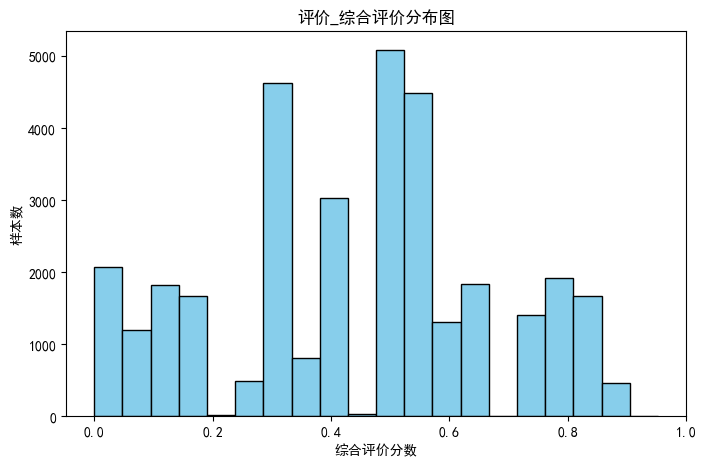

In [240]:
# === 应用到 test ===
test['评价_综合评价'] = test.apply(score_overall, axis=1)

# === 画分布图 ===
plt.figure(figsize=(8,5))
plt.hist(test['评价_综合评价'], bins=20, color='skyblue', edgecolor='black')
plt.title('评价_综合评价分布图')
plt.xlabel('综合评价分数')
plt.ylabel('样本数')
plt.show()

In [241]:
# 查看结果
test[['核心卖点', '户型介绍', '周边配套', '交通出行', '客户反馈', '评价_综合评价']].sample(10)

,核心卖点,户型介绍,周边配套,交通出行,客户反馈,评价_综合评价
12337,轻轨旁+楼下永辉+精装拎包入住+小区安静宜居+金科品质楼盘,NaN,小区出门100米为永辉；公园：玉马公园，同景公园；医院：重医附二院江南分院，西郊医院,本小区距离轻轨6号线邱家湾地铁站500米，门口200米为公交站，通过三隧（真武山隧道、慈母山...,目前来看，排水慢，管道漏水，客观上看，厕所漏水,0.190476
10128,NaN,NaN,NaN,NaN,隔离噪声差，也算是，停车位少，就周边而言，楼道异味,0.000000
26683,房子是好房满五年的，红本在手。看房方便，翠园东晓未锁定。,NaN,西南边200米处是刚落成的水贝珠宝总部基地，以及水贝金银座。很多已经招商营业，是整个亚洲很大...,楼盘位于围岭山南边山脚下，东西贯通的太白路边上。西边788米处是文锦北路，直接到龙岗大道，可...,标准水平，物业服务差，说白了，垃圾投放区干净，隔音出色,0.428571
19421,景观楼层，采光视野好，中间套户型，位置佳,NaN,商场：百联奥特莱斯2.6公里，嘉购生活广场400米，徐泾北城广场950米，医院：德达医院1....,公交：710，1502、880到北新泾，青泸线，青黄专线、北青线、青凤徐专线。地铁：走路距离...,空气流通正常，社区干净,0.857143
10708,NaN,NaN,NaN,NaN,当然了，噪音少，也算是，房东好沟通,0.000000
24292,NaN,NaN,NaN,NaN,家具新颖，如果仔细看，电力供应稳定,0.666667
3973,精装修户型方正没有浪费面积环境优美采光好,此房是2019年建成的纯南格局没有浪费面积楼间距大采光充足,NaN,NaN,安全感强，总体方向上，阳台采光佳,0.809524
11886,央企横厅朝南四房，户型方正，视野好，诚心出售，次新小区,NaN,NaN,1）三桥七隧分别是：土主隧道+礼嘉大桥、井口隧道+大竹林大桥、双杯隧道+双杯大桥、大学城隧道...,我觉得，燃气费标准收取，反过来看，周边噪音中等，坦白说，地段条件普通,0.142857
19391,此房满五唯一售后公房，一楼有8平米院子，得房率高，户型方正,NaN,出小区北门就是凤岗路宣化路路菜市场，便利店，水果店，各式小吃一条街；另有巴黎春天大商场，龙之...,"江苏路地铁站2,11号线约500米（数据来自百度地图），一站距离静安寺，南上延安高架，西上内...",小区门禁有效，一般般，产权清晰，周边教育资源正常,0.476190
291,NaN,NaN,NaN,NaN,门锁完好，采光角度正常,0.333333


In [242]:
# test = test.loc[:, ~test.T.duplicated()]
test.sample(100)
test.to_csv('test_preview.csv', index=False)  # 或者 test.to_excel('test_preview.xlsx', index=False)

### 离群值、插值

In [243]:
# 读取 CSV 文件
test_preview = pd.read_csv('test_preview.csv')

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10756\902726957.py:2: DtypeWarning: Columns (4,14,32) have mixed types. Specify dtype option on import or set low_memory=False.
  test_preview = pd.read_csv('test_preview.csv')


In [244]:
# 删除所有object类型列
test_preview = test_preview.drop(columns=test_preview.select_dtypes(include=['object']).columns)
# 将 test_preview 中所有非 object 类型的列转换为 float
test_preview = test_preview.astype({col: 'float' for col in test_preview.columns if test_preview[col].dtype != 'O'})
test_preview.sample(10)

,ID,城市,区域,板块,建筑面积,套内面积,抵押信息,lon,lat,年份,...,供热费_最小,供热费_最大,供热费_均值,停车费_最小,停车费_最大,停车费_均值,环线_内环范围,环线_中环至外环范围,环线_外环范围,评价_综合评价
6066,1006066.0,0.0,112.0,87.0,93.75,72.36,NaN,117.731962,40.882492,2022.0,...,30.0,30.0,30.0,150.0,150.0,150.0,0.0,0.0,1.0,0.857143
33143,1033143.0,10.0,90.0,359.0,126.85,101.80,NaN,114.366927,24.040931,2022.0,...,NaN,NaN,NaN,600.0,600.0,600.0,0.0,0.0,0.0,0.809524
12398,1012398.0,2.0,9.0,591.0,103.17,85.04,NaN,107.567796,30.519990,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.523810
18292,1018292.0,3.0,57.0,316.0,161.76,128.17,NaN,121.567857,32.899074,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.904762
33223,1033223.0,10.0,90.0,798.0,76.64,63.55,NaN,114.444595,23.947940,2022.0,...,NaN,NaN,NaN,400.0,400.0,400.0,0.0,0.0,0.0,0.476190
27136,1027136.0,8.0,93.0,62.0,119.00,NaN,NaN,103.826498,26.069696,2022.0,...,NaN,NaN,NaN,250.0,250.0,250.0,0.0,0.0,0.0,0.333333
13556,1013556.0,2.0,78.0,987.0,126.60,NaN,NaN,107.408386,30.641953,2022.0,...,NaN,NaN,NaN,400.0,400.0,400.0,1.0,0.0,0.0,0.761905
24521,1024521.0,5.0,125.0,237.0,192.68,155.44,NaN,114.557147,23.245404,2022.0,...,NaN,NaN,NaN,300.0,300.0,300.0,0.0,0.0,0.0,0.142857
3165,1003165.0,0.0,68.0,830.0,104.09,NaN,NaN,117.548635,40.943059,2022.0,...,30.0,30.0,30.0,150.0,150.0,150.0,0.0,1.0,0.0,0.095238
798,1000798.0,0.0,28.0,1131.0,186.68,NaN,NaN,117.366224,40.793249,2022.0,...,30.0,30.0,30.0,NaN,NaN,NaN,0.0,0.0,1.0,0.809524


In [245]:
for col, dtype in zip(test_preview.columns, test_preview.dtypes):
    print(col, dtype)

ID float64
城市 float64
区域 float64
板块 float64
建筑面积 float64
套内面积 float64
抵押信息 float64
lon float64
lat float64
年份 float64
区县 float64
板块_comm float64
房屋总数 float64
楼栋总数 float64
绿化率 float64
容积率 float64
停车位 float64
coord_x float64
coord_y float64
房型_室 float64
房型_厅 float64
房型_厨 float64
房型_卫 float64
房型_房间 float64
相对楼层_中楼层 float64
相对楼层_低楼层 float64
相对楼层_地下室 float64
相对楼层_底层 float64
相对楼层_顶层 float64
相对楼层_高楼层 float64
总共楼层 float64
朝向_东 float64
朝向_南 float64
朝向_西 float64
朝向_北 float64
结构_未知结构 float64
结构_框架结构 float64
结构_混合结构 float64
结构_砖木结构 float64
结构_砖混结构 float64
结构_钢混结构 float64
结构_钢结构 float64
装修_其他 float64
装修_毛坯 float64
装修_简装 float64
装修_精装 float64
梯户_电梯 float64
梯户_每层户数 float64
有电梯 float64
是否别墅 float64
交易_年 float64
交易_月 float64
交易_日 float64
交易权属_商品房 float64
交易权属_安置房 float64
交易权属_已购公房 float64
交易权属_私产或央产房 float64
交易权属_经济适用房 float64
交易权属_自住型商品房 float64
上次交易_年 float64
上次交易_月 float64
上次交易_日 float64
房屋用途_住宅 float64
房屋用途_公寓 float64
房屋用途_商业 float64
房屋用途_车库 float64
年限_满五 float64
年限_满二 float64
年限_未满二 float64
共有产权 f

In [246]:
# 计算每一列缺失值的比例
missing_percentage = test_preview.isnull().mean() * 100

# 输出缺失值比例大于 35% 的列
high_missing_columns = missing_percentage[missing_percentage > 35]
print(f"缺失值超过35%的列:\n{high_missing_columns}")

# 删除这些列
# test_preview = test_preview.drop(columns=high_missing_columns.index)  # 确保删除的是正确的列

# 输出处理后的数据集
print(test_preview.sample(10))

缺失值超过35%的列:
套内面积        70.852809
抵押信息       100.000000
供暖_集中供暖     73.263368
供暖_自采暖      76.435312
供暖_无供暖      98.753564
供热费_最小      67.695564
供热费_最大      67.695564
供热费_均值      67.695564
dtype: float64
              ID   城市     区域      板块    建筑面积   套内面积  抵押信息         lon  \
5879   1005879.0  0.0   65.0   173.0  123.74    NaN   NaN  117.470038   
10099  1010099.0  2.0   86.0   756.0   80.60    NaN   NaN  107.559443   
20695  1020695.0  4.0  129.0   955.0  108.94    NaN   NaN  122.534325   
2560   1002560.0  0.0  123.0  1103.0  135.29    NaN   NaN  117.689662   
14802  1014802.0  3.0   33.0   322.0   59.43    NaN   NaN  122.153572   
19326  1019326.0  4.0  122.0   494.0  112.85    NaN   NaN  122.509365   
24941  1024941.0  5.0   63.0   810.0   86.61  69.41   NaN  114.357020   
13168  1013168.0  2.0   78.0   349.0  107.20  86.18   NaN  107.341834   
5122   1005122.0  0.0  109.0   582.0   60.80    NaN   NaN  117.392490   
2023   1002023.0  0.0    7.0   865.0   68.26    NaN   NaN  117.3535

In [247]:
# 输出缺失值比例小于 20% 的列
low_missing_columns = missing_percentage[missing_percentage <= 20]
low_missing_columns

ID            0.0
城市            0.0
区域            0.0
板块            0.0
建筑面积          0.0
             ... 
产权_其他类        0.0
环线_内环范围       0.0
环线_中环至外环范围    0.0
环线_外环范围       0.0
评价_综合评价       0.0
Length: 77, dtype: float64

## 特征工程

In [250]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV, LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 假设 test_preview 已经是你的 DataFrame
test = test_preview.copy()

In [251]:
import pandas as pd
import numpy as np

# 需要处理的数值列（保持你给出的顺序，可增减）
num_cols = [
    '物业费_最小', '物业费_最大', '物业费_均值',
    '停车位', '上次交易_年', '燃气费_最小',
    '燃气费_最大', '燃气费_均值', '年份',
    '交易_年', '建筑物龄期', '建筑年份',
    '建筑面积', '房屋总数', '栋均户数_log',
    '栋均户数'
]

# 确保这些列都在 test 里
num_cols = [c for c in num_cols if c in test.columns]

def clip_outliers_iqr(df, cols, k=1.5):
    """
    用 IQR 法把异常值缩到 [Q1-k*IQR, Q3+k*IQR]，不删样本。
    """
    df = df.copy()
    for col in cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# 原地覆盖，保持原名
test = clip_outliers_iqr(test, num_cols)

In [ ]:
wtest.sample(10)

,ID,城市,区域,板块,建筑面积,套内面积,抵押信息,lon,lat,年份,...,供热费_最小,供热费_最大,供热费_均值,停车费_最小,停车费_最大,停车费_均值,环线_内环范围,环线_中环至外环范围,环线_外环范围,评价_综合评价
15482,1015482.0,3.0,35.0,906.0,83.70,NaN,NaN,121.630818,32.311217,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.095238
17345,1017345.0,3.0,33.0,867.0,98.63,NaN,NaN,122.155058,32.430792,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,1.0,0.333333
4499,1004499.0,0.0,7.0,543.0,59.68,NaN,NaN,117.476441,40.887547,2022.0,...,24.0,30.0,27.0,80.0,80.0,80.0,0.0,1.0,0.0,0.571429
31941,1031941.0,10.0,32.0,45.0,73.18,NaN,NaN,114.442404,24.131101,2022.0,...,NaN,NaN,NaN,600.0,600.0,600.0,0.0,0.0,0.0,0.476190
15312,1015312.0,3.0,35.0,906.0,143.02,NaN,NaN,121.625695,32.303153,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.428571
28295,1028295.0,8.0,38.0,1054.0,120.80,106.34,NaN,103.792902,26.045628,2022.0,...,NaN,NaN,NaN,500.0,500.0,500.0,0.0,0.0,0.0,0.476190
31561,1031561.0,10.0,32.0,134.0,64.32,NaN,NaN,114.360904,24.152257,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.857143
32832,1032832.0,10.0,90.0,118.0,91.80,NaN,NaN,114.516055,23.957360,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.523810
19898,1019898.0,4.0,23.0,664.0,73.38,NaN,NaN,122.359198,32.257873,2022.0,...,NaN,NaN,NaN,150.0,150.0,150.0,0.0,0.0,1.0,0.476190
7321,1007321.0,1.0,88.0,292.0,81.46,63.29,NaN,117.867975,41.049145,2022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.000000
